### Importieren von Play package

In [1]:
import importlib
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import Play
import cartopy.crs as ccrs

xr.set_options(keep_attrs=True, display_expand_data=False)
np.set_printoptions(threshold=10, edgeitems=2)



#### Update nach änderung im Pythonfile

In [2]:
#Update Module
importlib.reload(Play.plot_one_var)
importlib.reload(Play.mask)

<module 'Play.mask' from '/home/pjunghans/BachelorArbeit/Play/mask.py'>

#### Mask ausprobieren

In [3]:
data_set = Play.shape_data.show_data_set("mrsol")
data_set_masked = Play.mask.mask_dataholes(data_set)


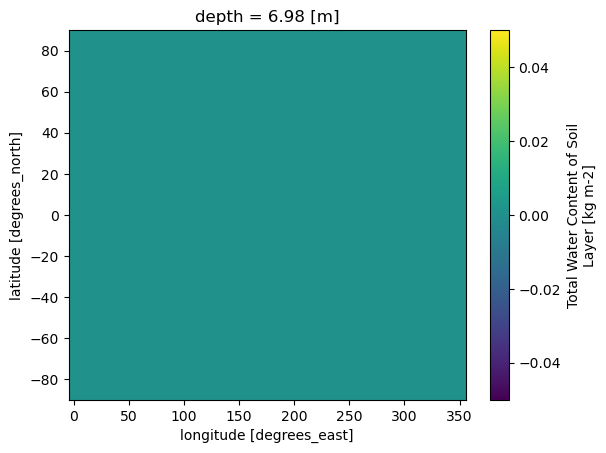

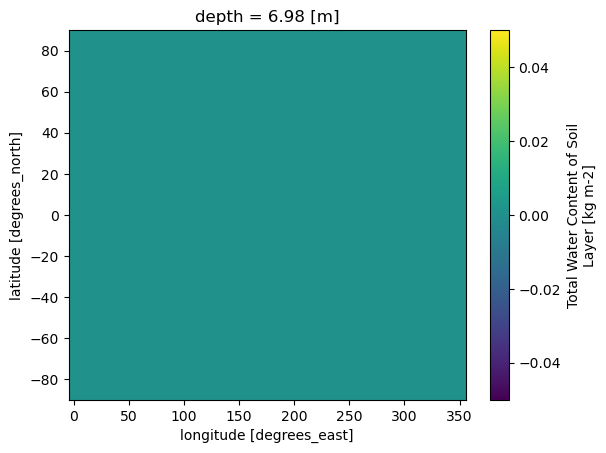

In [4]:
d = 4

((data_set["mrsol"].isel(depth = d) > 1e-4).all(dim = "time").astype(int)- (data_set_masked["mrsol"].isel(depth = d) > -100).any(dim = "time").astype(int)).plot()
plt.show()

(data_set["mrsol"].isel(depth = d) - data_set_masked["mrsol"].isel(depth = d)).sum(dim="time").plot()



#### Coastline Hintergründe

In [5]:
data_set = Play.shape_data.show_data_set("mrsol")
data_arr = data_set["mrsol"]
d = 3


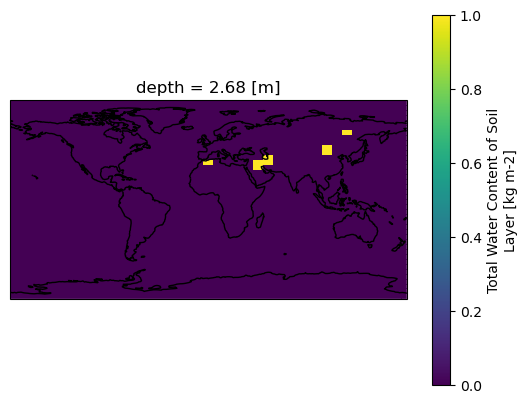

In [6]:
fig, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()}
)

((data_arr.isel(depth=d) <= 0).any(dim="time").astype(int)
 - (data_arr.isel(depth=d) <= 0).all(dim="time").astype(int)
).plot(ax=ax)

ax.coastlines()

plt.show()

In [22]:
mask.values[26,5]

np.int64(1)

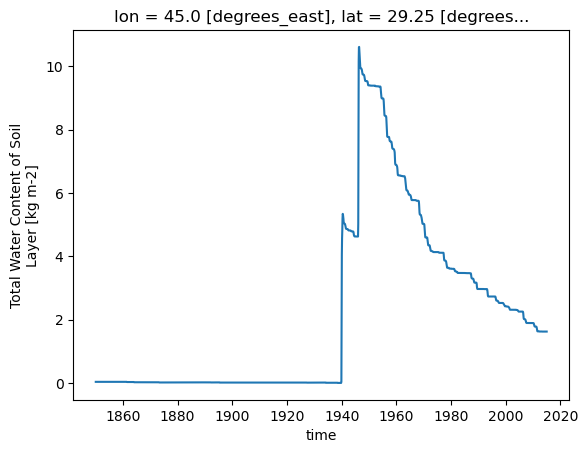

In [29]:
data_arr[:,3,26,5].plot()

In [ ]:
data_set = Play.shape_data.show_data_set("mrsol")
data_arr = data_set["mrsol"]
d = 3

mask = ((data_arr.isel(depth=d) <= 1e-4).any(dim="time").astype(int)
 - (data_arr.isel(depth=d) <= 0).all(dim="time").astype(int)
)

for y, x in zip(*np.where(mask)):

    data_arr[:,d,y,x].plot()

lat= 26 data 2.2204916956163507, lon=5 data 0.0, Wert=2.7159506347824642
lat= 27 data 7.79706554041587, lon=0 data 0.0, Wert=7.79706554041587
lat= 27 data 7.79706554041587, lon=5 data 0.0, Wert=9.78249232409745
lat= 27 data 7.79706554041587, lon=6 data 0.0, Wert=9.284564611195144
lat= 28 data 16.06601915806168, lon=6 data 0.0, Wert=7.7379585401592355
lat= 29 data 18.762899515837823, lon=12 data 0.0, Wert=7.051935893603716
lat= 30 data 20.106408330357173, lon=12 data 0.0, Wert=10.79544152265729
lat= 33 data nan, lon=14 data 0.0, Wert=16.463332959032158


#### Untersuchung von mrsol Datensets bounderies

In [ ]:
data_set = Play.shape_data.show_data_set("mrsol")

In [4]:
print(np.min(data_set["mrsol"]))

<xarray.DataArray 'mrsol' ()> Size: 8B
-0.3588
Attributes:
    standard_name:  mass_content_of_water_in_soil_layer
    long_name:      Total Water Content of Soil Layer
    units:          kg m-2
    comment:        in each soil layer, the mass of water in all phases, incl...
    original_name:  mrsol
    cell_methods:   area: mean where land time: mean
    cell_measures:  area: areacella
    history:        2019-09-11T14:22:11Z altered by CMOR: Reordered dimension...


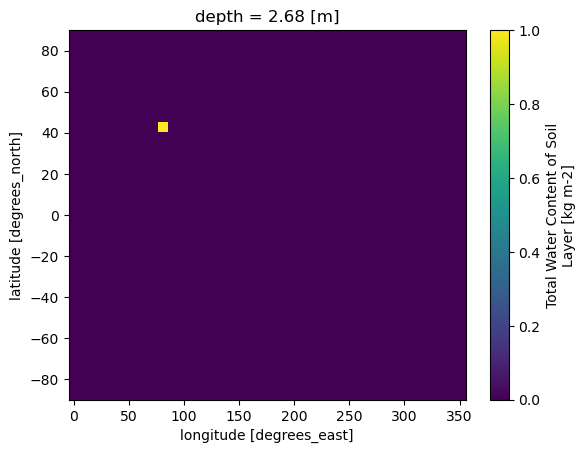

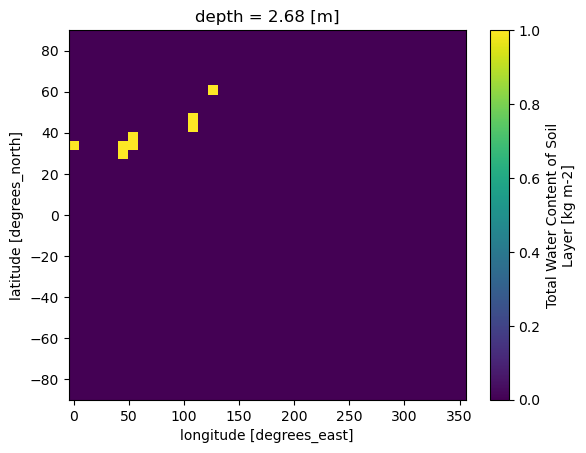

In [ ]:
#Achtung werte können negativ sein
data_arr = data_set["mrsol"]
    
if False:
    (data_arr.isel(depth = 4) < 1).any(dim = "time").astype(int).plot()
    plt.show()
    (data_arr.isel(depth = 4) < 1).all(dim = "time").astype(int).plot()
    plt.show()
    (data_arr.isel(depth = 4) <= 0).any(dim = "time").astype(int).plot()
    plt.show()
    (data_arr.isel(depth = 4) <= 0).all(dim = "time").astype(int).plot()
    plt.show()

d = 3 
# Threshhold
((data_arr.isel(depth = d) < 1e-4).any(dim = "time").astype(int) - (data_arr.isel(depth = d) <= 0).any(dim = "time").astype(int)).plot()

plt.show()
# not all
((data_arr.isel(depth = d) <= 0).any(dim = "time").astype(int)- (data_arr.isel(depth = d) <= 0).all(dim = "time").astype(int)).plot()
plt.show()


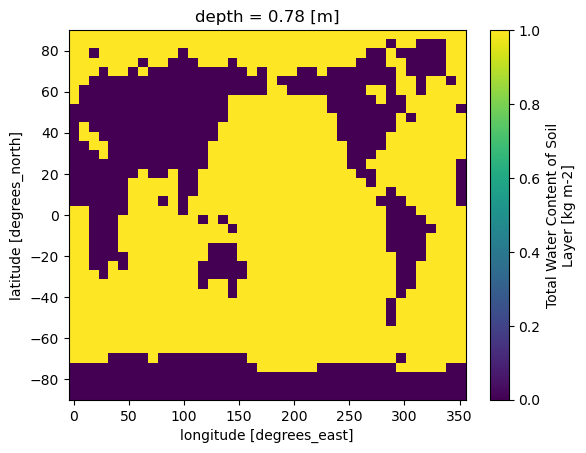

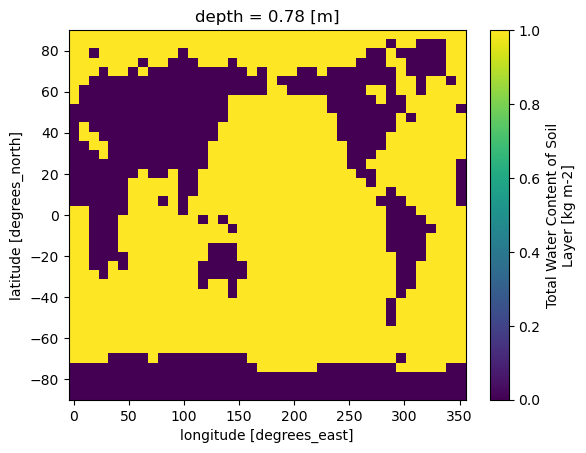

In [11]:
data_arr = data_set["mrsol"]
(data_arr.isel(depth = 2).isnull()).any(dim = "time").astype(int).plot()
plt.show()
(data_arr.isel(depth = 2).isnull()).all(dim = "time").astype(int).plot()
plt.show()

In [ ]:
#data_set["mrsol"].isel(depth = 0).plot(col= "time", col_wrap = 4, x = "lon");

KeyboardInterrupt: 

In [ ]:
xr.merge([output,output_estimated]).to_array().plot.line(hue="variable", x= "time")
output_estimated[output_var].plot(col="time", col_wrap = 4, x = "lon");
        

#### Erstelle Plots mit einem Datenset

mögliche Variabeln sind: temperature (tas), radiation (rsds), relative humidity (hurs), surface wind speed (sfcWind), soil moisture (mrsol), precipitation (pr)

Der Name wird für Ordner und file verwendet, während, das name_postfix etwas sein kann um spezifisch eine info in den Filenamen zu schreiben.



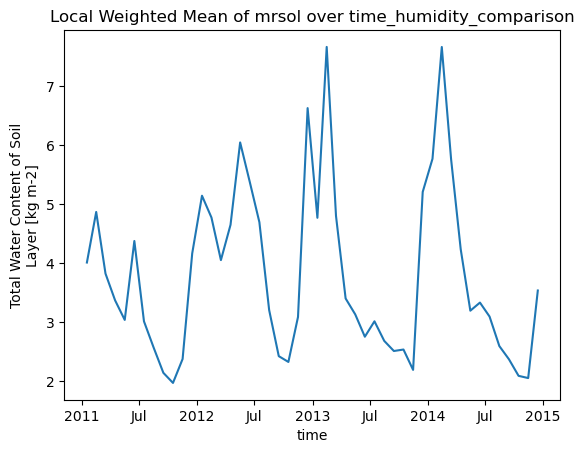

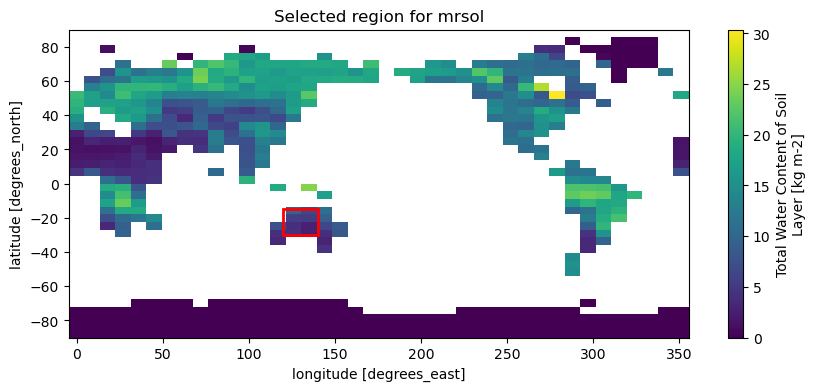

In [3]:
#def show_data_set(var = "tas", scen = "historical"):
#Play.plot_one_var.show_data_set(var = "tas",scen = "historical")

#def plot_mean_over_time(var = "tas", scen = "historical", name = "", name_postfix = ""):
#Play.plot_one_var.plot_mean_over_time(var = "tas",scen = "historical",name = "",name_postfix = "huhu") #historical oder ssp585

#def timeline_plots(var = "tas", scen = "historical", time_step = "10YE", number_of_plots = 10, depth = 1, save = False, name = "", name_postfix = ""):
#Play.plot_one_var.timeline_plots(var = "tas", scen = "historical", time_step = "10YE", number_of_plots = 10, save = True, name = "temperature_timeline", name_postfix = "historical")

#def plot_weighted_global_mean(var = "tas", scen = "historical", from_year = None, to_year = None, smoothed = False, depth = 1, save = False, name = "", name_postfix = ""):
#Play.plot_one_var.plot_weighted_global_mean(var = "mrsol", scen = "historical", smoothed = False, from_year = "1990", to_year = "2020", save = True, name = "humidity_comparison_Brasil_global_mean", name_postfix = "historical")

#def plot_weighted_local_mean(var = "tas", scen = "historical", from_lat = None, to_lat = None, from_lon = None, to_lon = None, from_year = None, to_year = None, smoothed = False, depth = 1, save = False, name = "", name_postfix = ""):
depth = 0
Play.plot_one_var.plot_weighted_local_mean(var = "mrsol", scen = "historical", from_lat = -30, to_lat=-15, from_lon=120, to_lon=140, from_year = "2011", to_year = "2015", smoothed = False, depth = depth, save = True, name = "humidity_comparison", name_postfix = f"Australia_depth_{depth}")